/tmp/ipykernel_24054/470982372.py:83: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_24054/470982372.py:83: UserWarning: Glyph 45937 (\N{HANGUL SYLLABLE DEG}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_24054/470982372.py:83: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_24054/470982372.py:83: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_24054/470982372.py:83: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_24054/470982372.py:83: UserWarning: Glyph 49496 (\N{HANGUL SYLLABLE SYEON}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_24054/470982372.py:83: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_24054/470982372.py:83: User

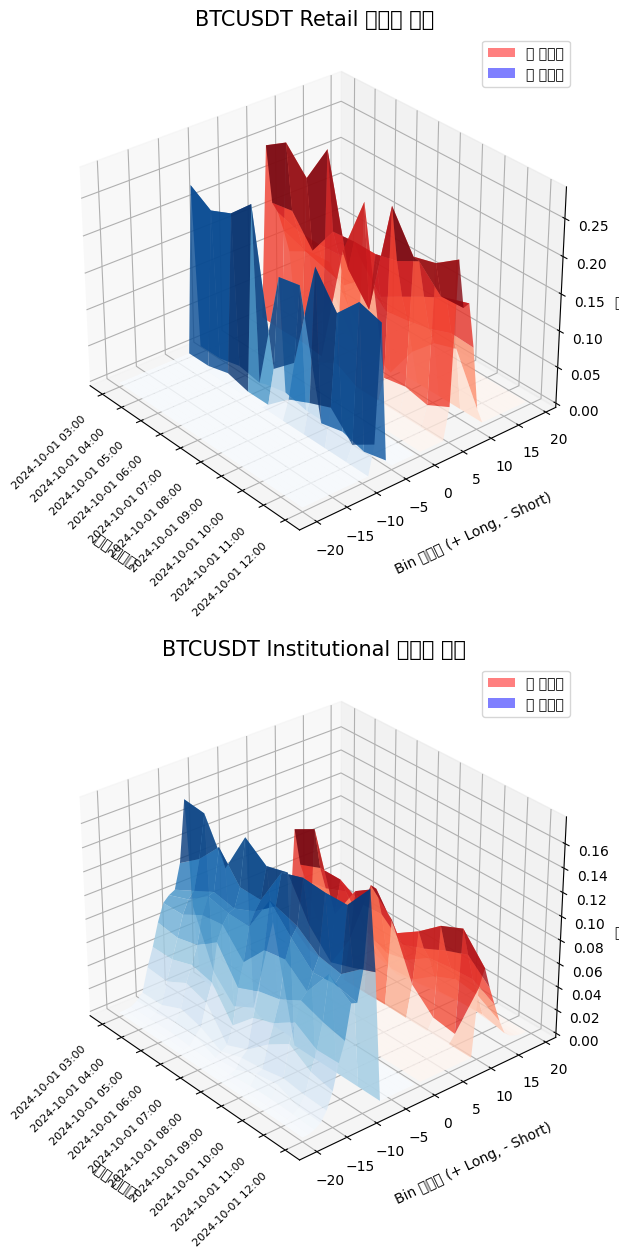

In [4]:
import os 
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D

# position distribution 디렉토리 내의 파일 탐색
file_path = "../data/binance/futures/um/monthly/position_distribution/3600000"

for file in os.listdir(file_path):
    csv_path = os.path.join(file_path, file)
    df = pd.read_csv(csv_path, index_col=0)  # retail_long, retail_short, institutional_long, institutional_short 컬럼은 list로 읽기
    df['retail_long'] = df['retail_long'].apply(lambda x: eval(x))
    df['retail_short'] = df['retail_short'].apply(lambda x: eval(x))
    df['institutional_long'] = df['institutional_long'].apply(lambda x: eval(x))
    df['institutional_short'] = df['institutional_short'].apply(lambda x: eval(x))

    # 날짜/시간 열을 인덱스로 설정 (CSV 파일의 실제 날짜/시간 열 이름으로 변경해주세요)
    df.index = pd.to_datetime(df.index)

    # 임의의 시작 index로부터 순서대로 1000개 row 추출
    n_samples = 10
    start_idx = np.random.randint(0, len(df) - n_samples)
    data_to_plot = df.iloc[start_idx:start_idx+n_samples]

    # 그래프 생성
    fig = plt.figure(figsize=(20, 15))

    # 개인(retail)과 기관(institutional) 그래프 생성
    categories = ["retail", "institutional"]
    for idx, category in enumerate(categories):
        ax = fig.add_subplot(2, 1, idx + 1, projection="3d")

        # 데이터 준비
        x_times = np.arange(len(data_to_plot))

        # long과 short 데이터를 하나의 그래프에 표시하기 위해 bin 인덱스 조정
        long_bins = np.arange(len(data_to_plot.iloc[0][f"{category}_long"]))
        short_bins = -np.arange(len(data_to_plot.iloc[0][f"{category}_short"]))[::-1] - 1

        # Long 데이터 처리
        X_long, Y_long = np.meshgrid(x_times, long_bins)
        Z_long = np.zeros((len(long_bins), len(x_times)))
        for i, time_idx in enumerate(x_times):
            Z_long[:, i] = data_to_plot.iloc[i][f"{category}_long"]

        # Short 데이터 처리
        X_short, Y_short = np.meshgrid(x_times, short_bins)
        Z_short = np.zeros((len(short_bins), len(x_times)))
        for i, time_idx in enumerate(x_times):
            Z_short[:, i] = data_to_plot.iloc[i][f"{category}_short"]

        # 3D 표면 그래프 그리기
        surf_long = ax.plot_surface(
            X_long, Y_long, Z_long, cmap="Reds", edgecolor="none", alpha=0.8, label="Long"
        )
        surf_short = ax.plot_surface(
            X_short, Y_short, Z_short, cmap="Blues", edgecolor="none", alpha=0.8, label="Short"
        )

        # 그래프 제목 및 레이블 설정
        ax.set_title(f"BTCUSDT {category.capitalize()} 포지션 분포", fontsize=15)
        ax.set_xlabel("시간 인덱스", labelpad=35)
        ax.set_ylabel("Bin 인덱스 (+ Long, - Short)", labelpad=15)
        ax.set_zlabel("빈도")

        # 실제 시간 표시를 위한 눈금 설정
        time_labels = [str(t)[:16] for t in data_to_plot.index]  # 날짜와 시간(시:분)까지 표시
        tick_interval = max(1, len(x_times) // 10)
        selected_ticks = x_times[::tick_interval]
        selected_labels = [time_labels[i] for i in selected_ticks]
        ax.set_xticks(selected_ticks)
        ax.set_xticklabels(selected_labels, rotation=45, ha="right", fontsize=8)

        # x축 라벨이 더 잘 보이도록 뷰 각도 조정
        ax.view_init(elev=30, azim=-40)

        # 범례 추가
        long_proxy = plt.Rectangle((0, 0), 1, 1, fc="red", alpha=0.5)
        short_proxy = plt.Rectangle((0, 0), 1, 1, fc="blue", alpha=0.5)
        ax.legend([long_proxy, short_proxy], ["롱 포지션", "숏 포지션"], loc="upper right")

    plt.tight_layout()
    plt.show()